In [1]:
import pandas as pd

from pool_genes import *

In [ ]:
from importlib import reload
import sys
if 'pool_genes' in sys.modules:
    reload(sys.modules['pool_genes'])

In [2]:
gene_df = pd.read_csv("../data/251114_gene_pair_pvalues.csv")
gene_df["pass_all"] = (
    (gene_df["p_spatial_fdr"] < 0.05)
    & (gene_df["p_rewired_fdr"] < 0.05)
    & (gene_df["p_gene_fdr"] < 0.05)
).astype(int)

risk_gene_df = pool_genes(gene_df, "risk gene")
clear_gene_df = pool_genes(gene_df, "clearance gene")

risk_gene_df = find_aliases(risk_gene_df)
clear_gene_df = find_aliases(clear_gene_df)

display(risk_gene_df.head())
display(clear_gene_df.head())

risk_gene_df.to_csv('../data/251114_risk_genes_pooled.csv', sep='\t', index=False)
clear_gene_df.to_csv('../data/251114_clearance_genes_pooled.csv', sep='\t', index=False)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
643 input query terms found dup hits:	[('A2M', 2), ('ACAT1', 2), ('ACAT2', 2), ('ACP1', 2), ('ACTB', 2), ('ADA2', 2), ('ADCY3', 2), ('ADK'
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
24 input query terms found dup hits:	[('BRAP', 2), ('BRI3', 2), ('CHMP4A', 2), ('CHMP4B', 2), ('COP1', 2), ('CTSO', 2), ('GBA', 2), ('GLA


,entrezgene,ensembl,symbol,abagen symbol,pass_all,num_pass,correlation,seed,score
0,1,ENSG00000121410,A1BG,A1BG,0.0,0.0,0.652410,59.0,0.0
1,2,ENSG00000175899,A2M,A2M,0.0,0.0,0.244633,18.0,0.0
2,144568,ENSG00000166535,A2ML1,A2ML1,0.0,0.0,0.377556,60.0,0.0
3,127550,ENSG00000184389,A3GALT2,A3GALT2,0.0,0.0,0.347508,18.0,0.0
4,53947,ENSG00000128274,A4GALT,A4GALT,0.0,0.0,0.384603,18.0,0.0


,entrezgene,ensembl,symbol,abagen symbol,pass_all,num_pass,correlation,seed,score
0,20,ENSG00000107331,ABCA2,ABCA2,1.0,0.000676,0.534274,25.0,0.000361
1,23457,ENSG00000150967,ABCB9,ABCB9,0.0,0.000000,0.384037,40.0,0.000000
2,1636,ENSG00000159640,ACE,ACE,0.0,0.000000,0.367533,49.0,0.000000
3,53,ENSG00000134575,ACP2,ACP2,0.0,0.000000,0.319797,32.0,0.000000
4,100,ENSG00000196839,ADA,ADA,0.0,0.000000,0.465045,59.0,0.000000


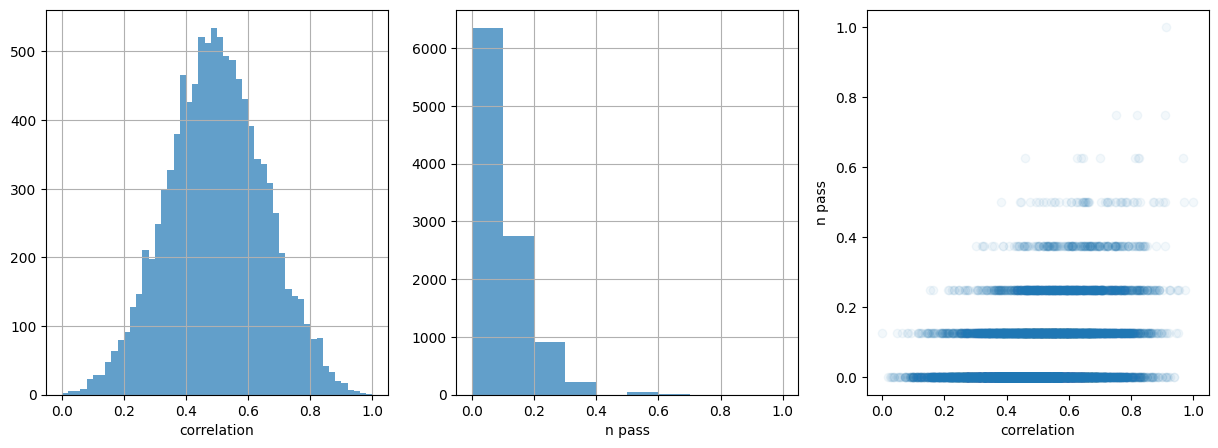

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
risk_gene_df["correlation"].hist(bins=50, alpha=0.7)
plt.xlabel("correlation")
plt.subplot(1, 3, 2)
risk_gene_df["num_pass"].hist(bins=10, alpha=0.7)
plt.xlabel("n pass")
plt.subplot(1, 3, 3)
plt.scatter(risk_gene_df["correlation"], risk_gene_df["num_pass"], alpha=0.05)
plt.xlabel("correlation")
plt.ylabel("n pass")
plt.show()

In [3]:
from get_disorder_data import *

degs = get_deg_consensus()
gwas_genes = get_gwas_combined()

display(degs.head())
display(gwas_genes.head())

,label,gene,study
2,SCZ,A2M,2
7,SCZ,ABCA17P,2
15,SCZ,ABCC12,2
27,SCZ,ABL2,2
28,SCZ,ABLIM2,2


,label,gene
0,SCZ,ABCB9
1,SCZ,ABHD2
2,SCZ,AC003088
3,SCZ,AC004159
4,SCZ,AC005609


In [ ]:
genes_of_interest = set(degs["gene"]).union(gwas_genes["gene"])
risk_genes_interest = risk_gene_df[risk_gene_df["abagen symbol"].isin(genes_of_interest)]
display(risk_genes_interest.head())
display(risk_gene_df.sort_values("score", ascending=False).head(10))

,entrezgene,ensembl,symbol,abagen symbol,pass_all,num_pass,correlation,seed,score
8912,8557,ENSG00000173991,TCAP,TCAP,1.0,1.000,0.912750,38.0,0.912750
6035,389493,ENSG00000185290,NUPR2,NUPR2,1.0,0.750,0.910580,60.0,0.682935
7055,83448,ENSG00000129317,PUS7L,PUS7L,1.0,0.750,0.820667,12.0,0.615500
2093,1525,ENSG00000154639,CXADR,CXADR,1.0,0.625,0.967846,31.0,0.604904
5744,10783,ENSG00000119408,NEK6,NEK6,1.0,0.750,0.752425,53.0,0.564319
8312,79677,ENSG00000163029,SMC6,SMC6,1.0,0.625,0.827501,31.0,0.517188
2359,79132,ENSG00000108771,DHX58,DHX58,1.0,0.625,0.823527,52.0,0.514704
974,119032,ENSG00000166275,BORCS7,BORCS7,1.0,0.625,0.814023,31.0,0.508765
9494,9256,ENSG00000005379,TSPOAP1,TSPOAP1,1.0,0.500,1.000000,38.0,0.500000
266,57491,ENSG00000063438,AHRR,AHRR,1.0,0.500,0.972404,31.0,0.486202


In [48]:
display(risk_gene_df["pass_all"].value_counts())

pass_all
0.0    6347
1.0    3960
Name: count, dtype: int64

In [40]:
eqtls_aa = pd.read_csv(
    r"/fs03/kg98/gchan/SIR_SCZ/SIR_utils/enrichment/pgcSCZ3_eQTLbrain_genes.txt",
    sep=r"\s+",
    engine="python"
)
eqtls_aa = eqtls_aa.rename(columns={"GENE": "Ensembl.ID"})
eqtls_aa = eqtls_aa[eqtls_aa["P"] < (0.05 / eqtls_aa.shape[0])].reset_index(drop=True)

eqtls_vt = pd.read_csv('/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/enrichment/41586_2022_4434_Tab1_ESM.csv')
eqtls_vt = eqtls_vt[eqtls_vt['Ensembl.ID'].isin(risk_gene_df['ensembl'])].reset_index(drop=True)
print(eqtls_aa.shape, eqtls_vt.shape)

(643, 11) (59, 7)


In [41]:
import numpy as np
from tqdm import tqdm


# Step 1: Calculate the Enrichment Score (ES)
def calculate_es(gene_list, gene_set):
    N = len(gene_list)
    Nh = len(gene_set)
    hits = np.isin(gene_list, list(gene_set)).astype(int)
    no_hits = 1 - hits

    # Calculate the running sum
    running_sum = np.cumsum(hits / Nh - no_hits / (N - Nh))
    es = running_sum.max()
    return es


# Step 2: Estimate the Statistical Significance (Nominal P value)
def permute_and_calculate_es(gene_list, gene_set, n_permutations=1000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    permuted_es = np.zeros(n_permutations)
    for i in tqdm(range(n_permutations)):
        permuted_list = np.random.permutation(gene_list)
        permuted_es[i] = calculate_es(permuted_list, gene_set)
    return permuted_es


def run_gsea(gene_list, gene_set, n_permutations=1000):
    observed_es = calculate_es(gene_list, gene_set)
    permuted_es = permute_and_calculate_es(gene_list, gene_set, n_permutations)
    p_value = np.mean(permuted_es >= observed_es)

    print(f"Observed ES: {observed_es}")
    print(f"Empirical P value: {p_value}")

    return observed_es, permuted_es

In [47]:
all_names = risk_gene_df.sort_values(by="score", ascending=False)
gene_list = all_names["ensembl"].tolist()

# with AA eQTLs as gene set, risk gene score as gene list
gene_set = set(eqtls_aa["Ensembl.ID"].tolist())
print("AA eQTLs as gene set, risk gene score as gene list")
obs, perm = run_gsea(gene_list, gene_set, n_permutations=1000)

# with VT eQTLs as gene set, risk gene score as gene list
gene_set = set(eqtls_vt["Ensembl.ID"].tolist())
print("VT eQTLs as gene set, risk gene score as gene list")
obs, perm = run_gsea(gene_list, gene_set, n_permutations=1000)


AA eQTLs as gene set, risk gene score as gene list


100%|██████████| 1000/1000 [01:21<00:00, 12.23it/s]


Observed ES: 0.0008339298404622373
Empirical P value: 0.224
VT eQTLs as gene set, risk gene score as gene list


100%|██████████| 1000/1000 [00:09<00:00, 110.55it/s]

Observed ES: 0.0909263816668649
Empirical P value: 0.373


In [44]:
import scipy.stats as stats

# Example data
experimental_hits = set(risk_gene_df[risk_gene_df["score"] > 0]["ensembl"].values)
pathway_genes = set(eqtls_aa["Ensembl.ID"].values)
all_genes = set(risk_gene_df["ensembl"].values)
non_hits = all_genes - experimental_hits

# Calculate the counts for the contingency table
hits_in_pathway = len(experimental_hits & pathway_genes)
hits_not_in_pathway = len(experimental_hits) - hits_in_pathway
non_hits_in_pathway = len(non_hits & pathway_genes)
non_hits_not_in_pathway = len(non_hits) - non_hits_in_pathway

# Create the contingency table
contingency_table = [
    [hits_in_pathway, hits_not_in_pathway],
    [non_hits_in_pathway, non_hits_not_in_pathway],
]

# Perform Fisher's Exact Test
odds_ratio, p_value = stats.fisher_exact(contingency_table)

print(contingency_table)
print(f"Odds Ratio: {odds_ratio}")
print(f"P-value: {p_value}")

[[87, 3863], [151, 6179]]
Odds Ratio: 0.9215858381349292
P-value: 0.5897997390266243


In [5]:
mg = mygene.MyGeneInfo()
gene_symbol = mg.querymany(
    eqtls["Ensembl.ID"].values.tolist(),
    fields="symbol",
    species="human",
    as_dataframe=True,
)

print(gene_symbol["symbol"].head().to_list())
gene_symbol["symbol"].to_csv("./eqtl_genes.csv", sep=",", index=False)

,Ensembl.ID,CHR,START,STOP,NSNPS,NPARAM,N,ZSTAT,P,PERMP,NPERM
0,ENSG00000215788,1,6521211,6526255,140,19,10000,4.6144,1.971500e-06,0.0001,10000
1,ENSG00000171680,1,6526152,6580121,195,21,10000,5.6463,8.196500e-09,0.0001,10000
2,ENSG00000162426,1,8377886,8404227,55,8,10000,6.7874,5.708700e-12,0.0001,10000
3,ENSG00000060656,1,29563028,29653325,36,5,10000,6.7014,1.032300e-11,0.0001,10000
4,ENSG00000066056,1,43766664,43788779,245,15,10000,5.1035,1.667100e-07,0.0001,10000


Input sequence provided is already in string format. No operation performed
20 input query terms found no hit:	['ENSG00000231196', 'ENSG00000273486', 'ENSG00000249034', 'ENSG00000124529', 'ENSG00000261353', 'ENS


,_id,_score,symbol,notfound
query,,,,
ENSG00000215788,8718,32.849766,TNFRSF25,NaN
ENSG00000171680,57449,32.849953,PLEKHG5,NaN
ENSG00000162426,50651,32.849632,SLC45A1,NaN
ENSG00000060656,10076,32.849630,PTPRU,NaN
ENSG00000066056,7075,31.832382,TIE1,NaN


In [ ]:
# Extract counts and p-values for the genes in the pathway
pathway_data = eqtls[eqtls["GENE"].isin(all_genes)]
counts = all_names.set_index("ensembl").loc[pathway_data["GENE"], "max_corr"]
p_values = pathway_data["p bonferroi"]

# Calculate Spearman's rank correlation
spearman_corr, spearman_p_value = stats.spearmanr(counts, p_values)

print(f"Spearman Correlation: {spearman_corr}")
print(f"Spearman P-value: {spearman_p_value}")

Spearman Correlation: -0.02190030855487883
Spearman P-value: 0.051643007682471195
